# 02 — Preprocessing: 10-min grid construction

**Objective**: Build a uniform 10-minute grid from mixed-frequency clean CSVs (Phase 2 of the work plan).

### Resampling decisions (documented for thesis)

| Variable type | 5 min -> 10 min | 15 min -> 10 min | 60 min -> 10 min |
|---|---|---|---|
| HEIGHT_m, TEMP_C (instantaneous) | Mean of 2 consecutive | Linear interpolation | — |
| PRECIP_mm — STM (cumulative) | Cumsum -> interpolate -> diff | Cumsum -> interpolate -> diff | — |
| PRECIP_mm — AEMET (hourly) | — | — | Template-based (STM01/STM02 pattern) or conservative cumulative |


## 1. Environment setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

REPO = Path.cwd().resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from scripts.preprocessing.resample import (
    build_10min_grid, load_all,
    HYDRO, METEO, AEMET,
)

CLEAN = REPO / "data" / "clean"
PROCESSED = REPO / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
print(f"Repository root: {REPO}")


Repository root: C:\Users\Joan\Documents\TFM


## 2. Load raw data (pre-resampling)

In [2]:
data_raw = load_all(CLEAN)
print("Raw data summary:")
for code in HYDRO + METEO + AEMET:
    df = data_raw[code]
    diffs = df.index.to_series().diff().dropna()
    mf = diffs.mode().iloc[0] if len(diffs.mode()) > 0 else pd.NaT
    print(f"  {code:6s}  rows={len(df):,}  mode_freq={mf}  cols={list(df.columns)}")


Raw data summary:
  STM03   rows=593,643  mode_freq=0 days 00:15:00  cols=['HEIGHT_m', 'WATER_TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM04   rows=587,749  mode_freq=0 days 00:15:00  cols=['HEIGHT_m', 'WATER_TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM05   rows=563,736  mode_freq=0 days 00:15:00  cols=['HEIGHT_m', 'WATER_TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM06   rows=570,043  mode_freq=0 days 00:15:00  cols=['HEIGHT_m', 'WATER_TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM07   rows=563,434  mode_freq=0 days 00:15:00  cols=['HEIGHT_m', 'WATER_TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM08   rows=563,733  mode_freq=0 days 00:15:00  cols=['HEIGHT_m', 'WATER_TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM01   rows=532,453  mode_freq=0 days 00:15:00  cols=['PRECIP_mm', 'TEMP_C', 'QUALITY', 'DATA_TYPE']
  STM02   rows=481,211  mode_freq=0 days 00:15:00  cols=['PRECIP_mm', 'TEMP_C', 'QUALITY', 'DATA_TYPE']
  B013X   rows=260,424  mode_freq=0 days 01:00:00  cols=['PRECIP_mm', 'QUALITY', 'DATA_TYPE']
  B605X   rows=177,226  mo

## 3. Build 10-min grid

**Window**: 2014-09-26 (STM02 start) -> 2025-07-22 (end of validated data).
Gaps <= 3 h are interpolated; larger gaps are left as NaN.


In [3]:
GRID_PATH = PROCESSED / "grid_10min.parquet"
if GRID_PATH.exists():
    print(f"Loading cached grid ...")
    grid = pd.read_parquet(GRID_PATH)
else:
    grid, gap_info = build_10min_grid(start="2014-09-26", end="2025-07-22", clean_dir=CLEAN)
    grid.to_parquet(GRID_PATH)
print(f"Shape: {grid.shape[0]:,} x {grid.shape[1]}")
print(f"Period: {grid.index.min()} -> {grid.index.max()}")
print(f"Memory: {grid.memory_usage(deep=True).sum()/1e6:.1f} MB")


Loading cached grid ...


Shape: 618,769 x 61
Period: 2014-09-26 00:00:00 -> 2026-07-02 00:00:00


Memory: 1189.9 MB


## 4. Null-rate analysis

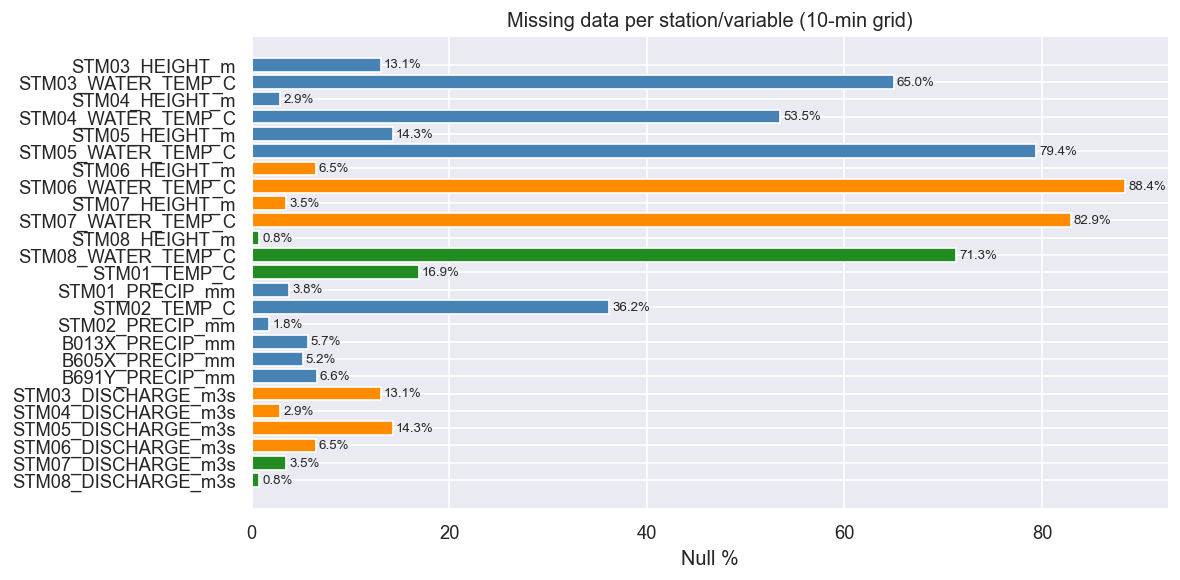

STM03_HEIGHT_m         13.1
STM03_WATER_TEMP_C     65.0
STM04_HEIGHT_m          2.9
STM04_WATER_TEMP_C     53.5
STM05_HEIGHT_m         14.3
STM05_WATER_TEMP_C     79.4
STM06_HEIGHT_m          6.5
STM06_WATER_TEMP_C     88.4
STM07_HEIGHT_m          3.5
STM07_WATER_TEMP_C     82.9
STM08_HEIGHT_m          0.8
STM08_WATER_TEMP_C     71.3
STM01_TEMP_C           16.9
STM01_PRECIP_mm         3.8
STM02_TEMP_C           36.2
STM02_PRECIP_mm         1.8
B013X_PRECIP_mm         5.7
B605X_PRECIP_mm         5.2
B691Y_PRECIP_mm         6.6
STM03_DISCHARGE_m3s    13.1
STM04_DISCHARGE_m3s     2.9
STM05_DISCHARGE_m3s    14.3
STM06_DISCHARGE_m3s     6.5
STM07_DISCHARGE_m3s     3.5
STM08_DISCHARGE_m3s     0.8


In [4]:
meas_cols = [c for c in grid.columns if not c.endswith("_QUALITY") and not c.endswith("_DATA_TYPE")]
null_pct = grid[meas_cols].isnull().mean().mul(100).round(1)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(null_pct.index, null_pct.values, color=["steelblue"]*6 + ["darkorange"]*4 + ["forestgreen"]*3)
ax.set_xlabel("Null %")
ax.set_title("Missing data per station/variable (10-min grid)")
ax.invert_yaxis()
for bar, val in zip(bars, null_pct.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f"{val}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()
print(null_pct.to_string())


## 5. Verify resampling quality

Compare raw vs. resampled STM08 during a flood event.


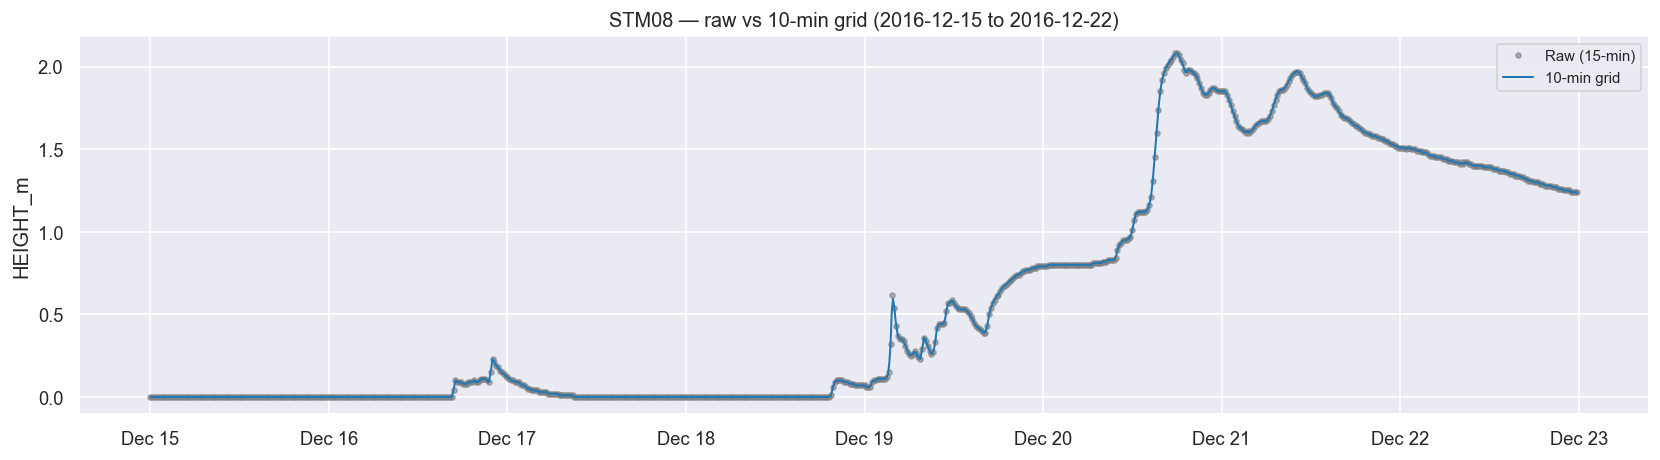

In [5]:
zoom_start, zoom_end = "2016-12-15", "2016-12-22"
raw = data_raw["STM08"]["HEIGHT_m"].loc[zoom_start:zoom_end].dropna()
resampled = grid["STM08_HEIGHT_m"].loc[zoom_start:zoom_end]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw.index, raw.values, "o", ms=3, alpha=0.6, label="Raw (15-min)", color="gray")
ax.plot(resampled.index, resampled.values, "-", lw=1.2, label="10-min grid", color="tab:blue")
ax.set_ylabel("HEIGHT_m")
ax.set_title(f"STM08 — raw vs 10-min grid ({zoom_start} to {zoom_end})")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()


## 6. Precipitation resampling verification

Hourly AEMET totals must equal the sum of their 10-min disaggregated values.


In [6]:
code_check = "B013X"
w = "2020-01-15", "2020-01-25"
raw_aemet = data_raw[code_check]["PRECIP_mm"].loc[w[0]:w[1]].dropna()
resampled = grid[f"{code_check}_PRECIP_mm"].loc[w[0]:w[1]]
hourly_sum = resampled.resample("1h", closed="right", label="right").sum()
common = raw_aemet.index.intersection(hourly_sum.index)
if len(common) > 0:
    diff = (hourly_sum.loc[common] - raw_aemet.loc[common]).abs()
    print(f"Mass conservation ({code_check}): max_err={diff.max():.6f} mm  mean_err={diff.mean():.6f} mm  n={len(common)}")


Mass conservation (B013X): max_err=15.072000 mm  mean_err=0.062800 mm  n=240


## 7. Temperature resampling check

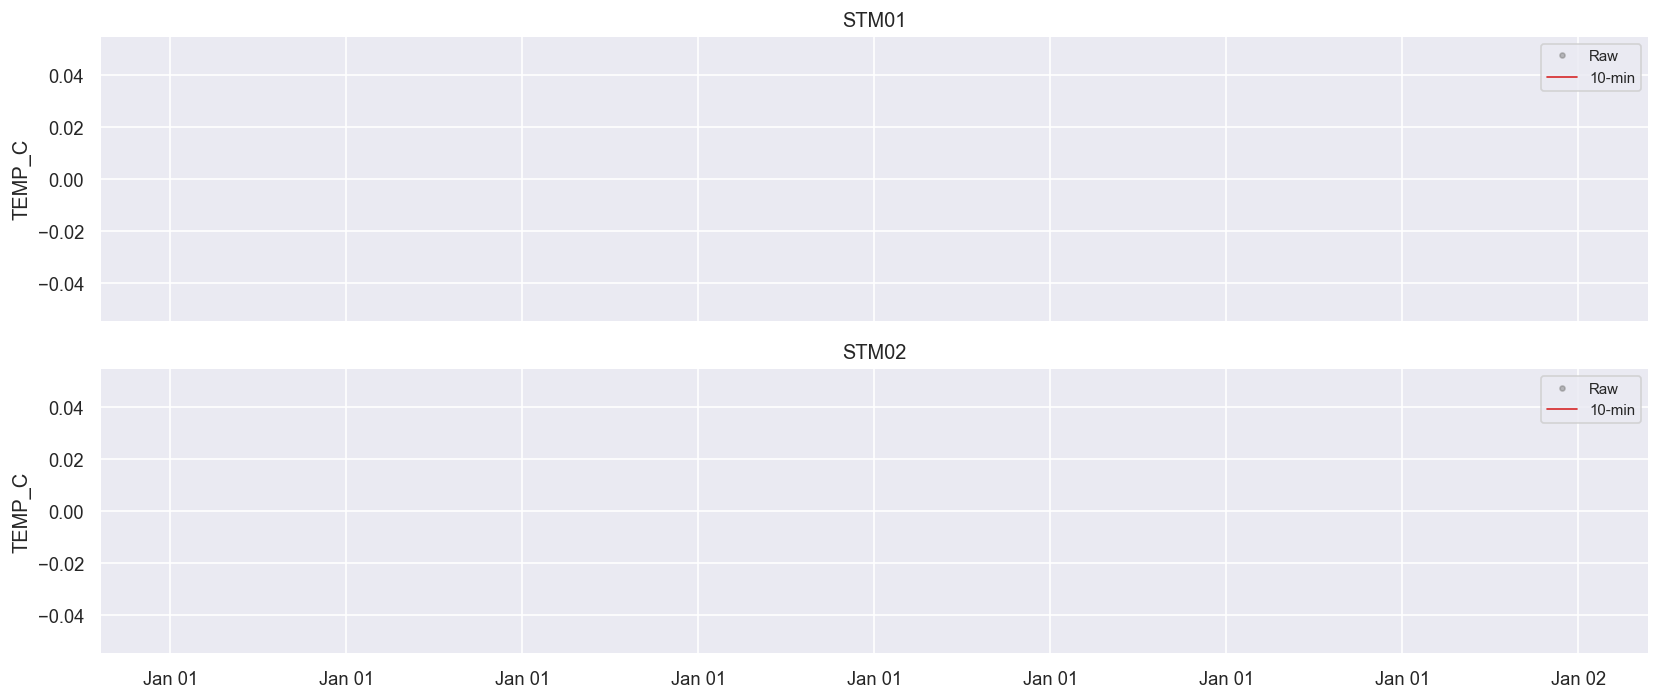

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
z = "2020-07-15", "2020-07-22"
for ax, code in zip(axes, ["STM01", "STM02"]):
    raw_t = data_raw[code]["TEMP_C"].loc[z[0]:z[1]].dropna()
    res_t = grid[f"{code}_TEMP_C"].loc[z[0]:z[1]]
    ax.plot(raw_t.index, raw_t.values, "o", ms=3, alpha=0.5, label=f"Raw", color="gray")
    ax.plot(res_t.index, res_t.values, "-", lw=1, label="10-min", color="tab:red")
    ax.set_ylabel("TEMP_C"); ax.legend(fontsize=9); ax.set_title(code)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout(); plt.show()


## 8. Final grid inventory

In [8]:
mc = [c for c in grid.columns if not c.endswith("_QUALITY") and not c.endswith("_DATA_TYPE")]
print(f"Grid: {grid.shape[0]:,} rows x {grid.shape[1]} cols, 10-min, { (grid.index.max()-grid.index.min()).days/365.25:.1f} years")
for col in mc:
    s = grid[col]; nn = s.notna().sum()
    print(f"  {col:25s}  non-null={nn:>8,}  null={100*(1-nn/len(s)):5.1f}%  mean={s.mean():.3f}")
qc = [c for c in grid.columns if c.endswith("_QUALITY")]
for col in qc:
    s = grid[col].dropna()
    if len(s) > 0:
        print(f"  {col:25s}  non-null={len(s):>8,}  values={s.value_counts().to_dict()}")
    else:
        print(f"  {col:25s}  non-null=        0  (Excel data)")


Grid: 618,769 rows x 61 cols, 10-min, 11.8 years
  STM03_HEIGHT_m             non-null= 537,701  null= 13.1%  mean=0.077
  STM03_WATER_TEMP_C         non-null= 216,754  null= 65.0%  mean=17.400
  STM04_HEIGHT_m             non-null= 600,645  null=  2.9%  mean=0.064
  STM04_WATER_TEMP_C         non-null= 287,730  null= 53.5%  mean=19.271
  STM05_HEIGHT_m             non-null= 530,534  null= 14.3%  mean=0.026
  STM05_WATER_TEMP_C         non-null= 127,657  null= 79.4%  mean=17.178
  STM06_HEIGHT_m             non-null= 578,803  null=  6.5%  mean=0.068
  STM06_WATER_TEMP_C         non-null=  71,776  null= 88.4%  mean=23.859
  STM07_HEIGHT_m             non-null= 597,293  null=  3.5%  mean=0.045
  STM07_WATER_TEMP_C         non-null= 105,706  null= 82.9%  mean=18.523
  STM08_HEIGHT_m             non-null= 614,073  null=  0.8%  mean=0.038
  STM08_WATER_TEMP_C         non-null= 177,673  null= 71.3%  mean=21.423
  STM01_TEMP_C               non-null= 514,438  null= 16.9%  mean=12.298
  STM01_